<a href="https://colab.research.google.com/github/clobos/ECO5056_2026/blob/main/ECO5056_Semana02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparação entre Árvore de Decisão, Bagging e Random Forest — Regressão

Este notebook amplia o notebook anterior para realizar uma **comparação controlada** entre:

1. **Decision Tree Regressor**
2. **Bagging Regressor**
3. **Random Forest Regressor**

Todos os modelos utilizarão exatamente:

- o mesmo conjunto de dados;
- os mesmos preditores;
- a mesma variável resposta;
- a mesma divisão treino/teste;
- o mesmo pré-processamento;
- os mesmos 5 folds;
- a mesma métrica de seleção;
- as mesmas métricas finais;
- os mesmos tamanhos de amostra nas curvas de aprendizagem.

## Objetivo estatístico

Comparar desempenho e comportamento em termos de:

- viés;
- variância;
- overfitting;
- estabilidade;
- generalização.


## 1. Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    learning_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Versão do scikit-learn:", sklearn.__version__)

Versão do scikit-learn: 1.6.1


## 2. Carregamento dos dados

In [2]:
penguins = sns.load_dataset("penguins")

## 3. Inspeção inicial

In [3]:
print("Dimensões originais:", penguins.shape)

print("\nPrimeiras observações:")
display(penguins.head())

print("\nTipos das variáveis:")
display(penguins.dtypes)

print("\nValores ausentes:")
display(penguins.isna().sum())

Dimensões originais: (344, 7)

Primeiras observações:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



Tipos das variáveis:


,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object



Valores ausentes:


,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


## 4. Definição da variável resposta e dos preditores

A variável resposta é:

\[
y = \text{body\_mass\_g}
\]

Os mesmos preditores do notebook anterior serão mantidos.

In [4]:
variavel_resposta = "body_mass_g"

preditores_numericos = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm"
]

preditores_categoricos = [
    "species",
    "island",
    "sex"
]

preditores = preditores_numericos + preditores_categoricos

X = penguins[preditores].copy()
y = penguins[variavel_resposta].copy()

## 5. Remover apenas valores ausentes na variável resposta

As ausências nos preditores serão tratadas **dentro dos Pipelines**, evitando *data leakage*.

In [5]:
dados_validos = y.notna()

X = X.loc[dados_validos].copy()
y = y.loc[dados_validos].copy()

print("X:", X.shape)
print("y:", y.shape)

X: (342, 6)
y: (342,)


## 6. Separação única entre treinamento e teste

A mesma divisão será reutilizada por todos os modelos.

In [6]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Treinamento:", X_treino.shape)
print("Teste:", X_teste.shape)

Treinamento: (273, 6)
Teste: (69, 6)


## 7. Pré-processamento numérico

In [7]:
transformador_numerico = Pipeline(
    steps=[
        ("imputacao", SimpleImputer(strategy="median"))
    ]
)

## 8. Pré-processamento categórico

In [8]:
transformador_categorico = Pipeline(
    steps=[
        ("imputacao", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

## 9. `ColumnTransformer` comum aos três modelos

In [9]:
pre_processador = ColumnTransformer(
    transformers=[
        ("numericas", transformador_numerico, preditores_numericos),
        ("categoricas", transformador_categorico, preditores_categoricos)
    ]
)

## 10. Mesmos folds para todos os modelos

Todos os `GridSearchCV` e todas as curvas de aprendizagem utilizarão este mesmo objeto.

In [10]:
kfold_5 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [11]:
print('Indices de treino e validação para cada fold:')
for i, (idx_treino, idx_validacao) in enumerate(kfold_5.split(X_treino, y_treino)):
    print(f"\nFold {i+1}:")
    print(f"  Índices de Treino: {idx_treino[:5]}... (total: {len(idx_treino)})") # Mostra os 5 primeiros e o total
    print(f"  Índices de Validação: {idx_validacao[:5]}... (total: {len(idx_validacao)})") # Mostra os 5 primeiros e o total

Indices de treino e validação para cada fold:

Fold 1:
  Índices de Treino: [0 1 2 3 4]... (total: 218)
  Índices de Validação: [ 6  9 15 19 22]... (total: 55)

Fold 2:
  Índices de Treino: [0 1 3 4 5]... (total: 218)
  Índices de Validação: [ 2 10 16 18 29]... (total: 55)

Fold 3:
  Índices de Treino: [1 2 3 6 7]... (total: 218)
  Índices de Validação: [ 0  4  5 11 12]... (total: 55)

Fold 4:
  Índices de Treino: [0 2 4 5 6]... (total: 219)
  Índices de Validação: [ 1  3  7 23 34]... (total: 54)

Fold 5:
  Índices de Treino: [0 1 2 3 4]... (total: 219)
  Índices de Validação: [ 8 13 14 17 20]... (total: 54)


In [12]:
print(kfold_5.__dict__.keys())

dict_keys(['n_splits', 'shuffle', 'random_state'])


In [13]:
print([nome for nome in dir(kfold_5) if not nome.startswith("_")])

['get_metadata_routing', 'get_n_splits', 'n_splits', 'random_state', 'shuffle', 'split']


## 11. Modelo baseline

O `DummyRegressor` prevê a média da variável resposta e fornece uma referência mínima de desempenho.

In [14]:
modelo_baseline = DummyRegressor(strategy="mean")
modelo_baseline.fit(X_treino, y_treino)

pred_baseline = modelo_baseline.predict(X_teste)

rmse_baseline = np.sqrt(mean_squared_error(y_teste, pred_baseline))
mae_baseline = mean_absolute_error(y_teste, pred_baseline)
r2_baseline = r2_score(y_teste, pred_baseline)

print(f"RMSE baseline: {rmse_baseline:.2f} g")
print(f"MAE baseline : {mae_baseline:.2f} g")
print(f"R² baseline  : {r2_baseline:.3f}")

RMSE baseline: 819.59 g
MAE baseline : 693.15 g
R² baseline  : -0.010


In [15]:
atributos_ajustados = [
    nome for nome in dir(modelo_baseline)
    if nome.endswith("_") and not nome.startswith("_")
]

print(atributos_ajustados)

['constant_', 'feature_names_in_', 'n_features_in_', 'n_outputs_']


# Parte I — Árvore de Decisão

## 12. Pipeline da Árvore

In [16]:
pipeline_arvore = Pipeline(
    steps=[
        ("pre_processamento", pre_processador),
        ("modelo", DecisionTreeRegressor(random_state=42))
    ]
)

## 13. Grade de hiperparâmetros — Árvore

A complexidade será controlada por:

- `max_depth`;
- `min_samples_split`;
- `min_samples_leaf`.

In [17]:
grade_arvore = {
    "modelo__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "modelo__min_samples_split": [2, 5, 10, 20],
    "modelo__min_samples_leaf": [1, 2, 5, 10]
}

n_combinacoes_arvore = np.prod(
    [len(v) for v in grade_arvore.values()]
)

print("Combinações:", n_combinacoes_arvore)
print(
    "Ajustes aproximados com 5 folds:",
    n_combinacoes_arvore * kfold_5.get_n_splits()
)

Combinações: 128
Ajustes aproximados com 5 folds: 640


## 14. GridSearchCV — Árvore

In [18]:
busca_arvore = GridSearchCV(
    estimator=pipeline_arvore,
    param_grid=grade_arvore,
    cv=kfold_5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    error_score="raise"
)

busca_arvore.fit(X_treino, y_treino)

melhor_arvore = busca_arvore.best_estimator_

print("Melhores hiperparâmetros:")
print(busca_arvore.best_params_)
print(
    f"RMSE médio de validação cruzada: "
    f"{-busca_arvore.best_score_:.2f} g"
)

Melhores hiperparâmetros:
{'modelo__max_depth': 4, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 2}
RMSE médio de validação cruzada: 339.02 g


In [19]:
atributos_ajustados = [
    nome for nome in dir(busca_arvore)
    if nome.endswith("_") and not nome.startswith("_")
]

print(atributos_ajustados)

['best_estimator_', 'best_index_', 'best_params_', 'best_score_', 'classes_', 'cv_results_', 'feature_names_in_', 'multimetric_', 'n_features_in_', 'n_splits_', 'refit_time_', 'scorer_']


# Parte II — Bagging

O Bagging ajusta várias árvores em diferentes amostras e combina suas previsões.

A ideia principal é reduzir a variância de uma árvore individual por meio da agregação.

## 15. Pipeline do Bagging

In [20]:
pipeline_bagging = Pipeline(
    steps=[
        ("pre_processamento", pre_processador),
        (
            "modelo",
            BaggingRegressor(
                estimator=DecisionTreeRegressor(random_state=42),
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

## 16. Grade de hiperparâmetros — Bagging

In [21]:
grade_bagging = {
    "modelo__n_estimators": [50, 100, 200],
    "modelo__max_samples": [0.7, 1.0],
    "modelo__bootstrap": [True, False],
    "modelo__estimator__max_depth": [3, 5, None],
    "modelo__estimator__min_samples_leaf": [1, 5]
}

n_combinacoes_bagging = np.prod(
    [len(v) for v in grade_bagging.values()]
)

print("Combinações:", n_combinacoes_bagging)
print(
    "Ajustes aproximados com 5 folds:",
    n_combinacoes_bagging * kfold_5.get_n_splits()
)

Combinações: 72
Ajustes aproximados com 5 folds: 360


## 17. GridSearchCV — Bagging

In [22]:
busca_bagging = GridSearchCV(
    estimator=pipeline_bagging,
    param_grid=grade_bagging,
    cv=kfold_5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    error_score="raise"
)

busca_bagging.fit(X_treino, y_treino)

melhor_bagging = busca_bagging.best_estimator_

print("Melhores hiperparâmetros:")
print(busca_bagging.best_params_)
print(
    f"RMSE médio de validação cruzada: "
    f"{-busca_bagging.best_score_:.2f} g"
)

Melhores hiperparâmetros:
{'modelo__bootstrap': True, 'modelo__estimator__max_depth': 5, 'modelo__estimator__min_samples_leaf': 1, 'modelo__max_samples': 0.7, 'modelo__n_estimators': 200}
RMSE médio de validação cruzada: 307.14 g


In [23]:
atributos_ajustados = [
    nome for nome in dir(busca_bagging)
    if nome.endswith("_") and not nome.startswith("_")
]

print(atributos_ajustados)

['best_estimator_', 'best_index_', 'best_params_', 'best_score_', 'classes_', 'cv_results_', 'feature_names_in_', 'multimetric_', 'n_features_in_', 'n_splits_', 'refit_time_', 'scorer_']


# Parte III — Random Forest

A Random Forest acrescenta ao Bagging uma seleção aleatória de variáveis candidatas em cada divisão.

Isso reduz a correlação entre as árvores e pode diminuir ainda mais a variância do ensemble.

## 18. Pipeline da Random Forest

In [24]:
pipeline_floresta = Pipeline(
    steps=[
        ("pre_processamento", pre_processador),
        (
            "modelo",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

## 19. Grade de hiperparâmetros — Random Forest

In [25]:
grade_floresta = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [3, 5, 8, None],
    "modelo__min_samples_leaf": [1, 2, 5],
    "modelo__max_features": ["sqrt", 0.7, 1.0],
    "modelo__bootstrap": [True, False]
}

n_combinacoes_floresta = np.prod(
    [len(v) for v in grade_floresta.values()]
)

print("Combinações:", n_combinacoes_floresta)
print(
    "Ajustes aproximados com 5 folds:",
    n_combinacoes_floresta * kfold_5.get_n_splits()
)

Combinações: 216
Ajustes aproximados com 5 folds: 1080


## 20. GridSearchCV — Random Forest

In [26]:
busca_floresta = GridSearchCV(
    estimator=pipeline_floresta,
    param_grid=grade_floresta,
    cv=kfold_5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    error_score="raise"
)

busca_floresta.fit(X_treino, y_treino)

melhor_floresta = busca_floresta.best_estimator_

print("Melhores hiperparâmetros:")
print(busca_floresta.best_params_)
print(
    f"RMSE médio de validação cruzada: "
    f"{-busca_floresta.best_score_:.2f} g"
)

Melhores hiperparâmetros:
{'modelo__bootstrap': False, 'modelo__max_depth': 8, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 100}
RMSE médio de validação cruzada: 301.18 g


In [27]:
atributos_ajustados = [
    nome for nome in dir(busca_floresta)
    if nome.endswith("_") and not nome.startswith("_")
]

print(atributos_ajustados)

['best_estimator_', 'best_index_', 'best_params_', 'best_score_', 'classes_', 'cv_results_', 'feature_names_in_', 'multimetric_', 'n_features_in_', 'n_splits_', 'refit_time_', 'scorer_']


# Parte IV — Comparação durante a validação cruzada

## 21. Função para resumir o melhor modelo de cada busca

In [28]:
def resumo_cv(busca, nome_modelo):
    resultados = pd.DataFrame(busca.cv_results_)
    indice = busca.best_index_

    rmse_treino = -resultados.loc[indice, "mean_train_score"]
    rmse_validacao = -resultados.loc[indice, "mean_test_score"]
    dp_validacao = resultados.loc[indice, "std_test_score"]
    gap = rmse_validacao - rmse_treino

    return {
        "Modelo": nome_modelo,
        "RMSE_treino_CV": rmse_treino,
        "RMSE_validacao_CV": rmse_validacao,
        "Gap_CV": gap,
        "DP_validacao_CV": dp_validacao
    }

## 22. Tabela comparativa da validação cruzada

In [29]:
comparacao_cv = pd.DataFrame([
    resumo_cv(busca_arvore, "Árvore de decisão"),
    resumo_cv(busca_bagging, "Bagging"),
    resumo_cv(busca_floresta, "Random Forest")
])

comparacao_cv = comparacao_cv.sort_values(
    "RMSE_validacao_CV"
).reset_index(drop=True)

display(comparacao_cv)

,Modelo,RMSE_treino_CV,RMSE_validacao_CV,Gap_CV,DP_validacao_CV
0,Random Forest,224.819808,301.175972,76.356164,27.043211
1,Bagging,210.971899,307.137997,96.166097,34.461391
2,Árvore de decisão,250.752037,339.023125,88.271088,32.564842


### Interpretação

- **RMSE de validação menor:** melhor desempenho médio.
- **Gap maior:** possível maior variância.
- **DP maior:** maior instabilidade entre os folds.
- **Treino e validação ambos altos:** possível alto viés.

# Parte V — Avaliação final no mesmo conjunto de teste

## 23. Função comum de avaliação

In [30]:
def avaliar_modelo(modelo, X_teste, y_teste):
    predicoes = modelo.predict(X_teste)

    rmse = np.sqrt(
        mean_squared_error(y_teste, predicoes)
    )

    mae = mean_absolute_error(
        y_teste, predicoes
    )

    r2 = r2_score(
        y_teste, predicoes
    )

    return predicoes, rmse, mae, r2

## 24. Avaliar os três modelos (usar na prática somente o modelo vencedor)

In [31]:
pred_arvore, rmse_arvore, mae_arvore, r2_arvore = avaliar_modelo(
    melhor_arvore,
    X_teste,
    y_teste
)

pred_bagging, rmse_bagging, mae_bagging, r2_bagging = avaliar_modelo(
    melhor_bagging,
    X_teste,
    y_teste
)

pred_floresta, rmse_floresta, mae_floresta, r2_floresta = avaliar_modelo(
    melhor_floresta,
    X_teste,
    y_teste
)

## 25. Tabela comparativa no conjunto de teste

In [32]:
comparacao_teste = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Árvore de decisão",
        "Bagging",
        "Random Forest"
    ],
    "RMSE": [
        rmse_baseline,
        rmse_arvore,
        rmse_bagging,
        rmse_floresta
    ],
    "MAE": [
        mae_baseline,
        mae_arvore,
        mae_bagging,
        mae_floresta
    ],
    "R2": [
        r2_baseline,
        r2_arvore,
        r2_bagging,
        r2_floresta
    ]
})

comparacao_teste["Reducao_RMSE_vs_baseline_%"] = (
    (rmse_baseline - comparacao_teste["RMSE"])
    / rmse_baseline
) * 100

comparacao_teste = comparacao_teste.sort_values(
    "RMSE"
).reset_index(drop=True)

display(comparacao_teste)

,Modelo,RMSE,MAE,R2,Reducao_RMSE_vs_baseline_%
0,Random Forest,304.125585,249.482010,0.860897,62.893034
1,Bagging,309.173673,248.546464,0.856240,62.277107
2,Árvore de decisão,327.908786,263.480724,0.838290,59.991199
3,Baseline,819.591633,693.151776,-0.010245,0.000000


## 26. Melhor resultado no conjunto de teste

In [33]:
melhor_linha_teste = comparacao_teste.iloc[0]

print("Modelo com menor RMSE no teste:")
print(melhor_linha_teste["Modelo"])

print(
    f"RMSE = {melhor_linha_teste['RMSE']:.2f} g"
)

Modelo com menor RMSE no teste:
Random Forest
RMSE = 304.13 g


# Parte VIII — Curvas de aprendizagem comparáveis

As três curvas utilizarão exatamente:

- o mesmo conjunto de treinamento;
- o mesmo `kfold_5`;
- a mesma métrica;
- os mesmos tamanhos relativos;
- o mesmo `random_state`.

Assim, a comparação é diretamente interpretável.

## 34. Tamanhos comuns

In [34]:
train_sizes_comuns = np.linspace( 0.10,  1.0, 10)
train_sizes_comuns

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

## 35. Função única para calcular as curvas

In [35]:
def calcular_curva_aprendizagem(modelo):
    tamanhos, scores_treino, scores_validacao = learning_curve(
        estimator=modelo,
        X=X_treino,
        y=y_treino,
        cv=kfold_5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        train_sizes=train_sizes_comuns,
        shuffle=True,
        random_state=42
    )

    return {
        "tamanhos": tamanhos,
        "treino_media": -scores_treino.mean(axis=1),
        "treino_dp": scores_treino.std(axis=1),
        "validacao_media": -scores_validacao.mean(axis=1),
        "validacao_dp": scores_validacao.std(axis=1)
    }

## 36. Calcular as três curvas

In [36]:
curva_arvore = calcular_curva_aprendizagem(
    melhor_arvore
)

curva_bagging = calcular_curva_aprendizagem(
    melhor_bagging
)

curva_floresta = calcular_curva_aprendizagem(
    melhor_floresta
)

## 37. Tabela da curva — Árvore de decisão

In [37]:
tabela_curva_arvore = pd.DataFrame({
    "n_treinamento": curva_arvore["tamanhos"],
    "RMSE_treino": curva_arvore["treino_media"],
    "DP_treino": curva_arvore["treino_dp"],
    "RMSE_validacao": curva_arvore["validacao_media"],
    "DP_validacao": curva_arvore["validacao_dp"],
    "Gap": (
        curva_arvore["validacao_media"]
        - curva_arvore["treino_media"]
    )
})

display(tabela_curva_arvore)

,n_treinamento,RMSE_treino,DP_treino,RMSE_validacao,DP_validacao,Gap
0,21,163.209638,17.437954,535.859346,120.682074,372.649708
1,43,188.150054,30.136780,420.556392,71.646566,232.406337
2,65,208.731968,26.663103,423.957676,61.676141,215.225708
3,87,226.597652,10.573796,374.936935,57.241597,148.339284
4,109,232.095076,14.067172,358.928815,29.214250,126.833739
5,130,239.200809,8.686903,359.645265,36.136828,120.444456
6,152,243.680279,9.837014,352.827783,33.993850,109.147504
7,174,246.209191,6.611913,356.961188,51.013781,110.751997
8,196,244.038676,8.023927,335.512282,43.671851,91.473606
9,218,250.933719,3.378995,338.198766,33.594510,87.265047


## 38. Tabela da curva — Bagging

In [38]:
tabela_curva_bagging = pd.DataFrame({
    "n_treinamento": curva_bagging["tamanhos"],
    "RMSE_treino": curva_bagging["treino_media"],
    "DP_treino": curva_bagging["treino_dp"],
    "RMSE_validacao": curva_bagging["validacao_media"],
    "DP_validacao": curva_bagging["validacao_dp"],
    "Gap": (
        curva_bagging["validacao_media"]
        - curva_bagging["treino_media"]
    )
})

display(tabela_curva_bagging)

,n_treinamento,RMSE_treino,DP_treino,RMSE_validacao,DP_validacao,Gap
0,21,217.287481,7.735873,387.549242,29.116783,170.261761
1,43,182.904093,15.760452,347.879076,51.771195,164.974983
2,65,179.464089,9.030513,344.340276,25.511741,164.876187
3,87,187.367973,4.932449,335.512298,32.177658,148.144325
4,109,188.738725,9.997871,333.300615,34.131677,144.561889
5,130,194.272416,6.743561,319.119854,28.372370,124.847438
6,152,200.651918,7.159012,316.069334,27.126122,115.417416
7,174,206.153068,5.103826,315.624507,30.595975,109.471439
8,196,206.712560,4.798155,311.767026,28.081953,105.054466
9,218,212.107124,4.210302,305.989677,29.624812,93.882552


## 39. Tabela da curva — Random Forest

In [39]:
tabela_curva_floresta = pd.DataFrame({
    "n_treinamento": curva_floresta["tamanhos"],
    "RMSE_treino": curva_floresta["treino_media"],
    "DP_treino": curva_floresta["treino_dp"],
    "RMSE_validacao": curva_floresta["validacao_media"],
    "DP_validacao": curva_floresta["validacao_dp"],
    "Gap": (
        curva_floresta["validacao_media"]
        - curva_floresta["treino_media"]
    )
})

display(tabela_curva_floresta)

,n_treinamento,RMSE_treino,DP_treino,RMSE_validacao,DP_validacao,Gap
0,21,355.602079,46.006009,449.376796,59.098991,93.774716
1,43,259.470708,21.552404,355.894117,69.320293,96.423409
2,65,243.471353,10.392924,321.692358,36.414944,78.221005
3,87,240.131652,15.138465,319.712590,27.412201,79.580938
4,109,235.323533,16.243442,320.901835,31.907464,85.578302
5,130,229.547389,12.222515,308.992072,29.295577,79.444683
6,152,233.907247,8.536296,298.927420,24.598170,65.020173
7,174,232.899297,6.157391,305.312784,27.194309,72.413487
8,196,223.608143,6.680579,304.518170,28.504989,80.910027
9,218,225.095947,4.913158,300.849742,26.484810,75.753795


## 40. Curva de aprendizagem — Árvore de decisão

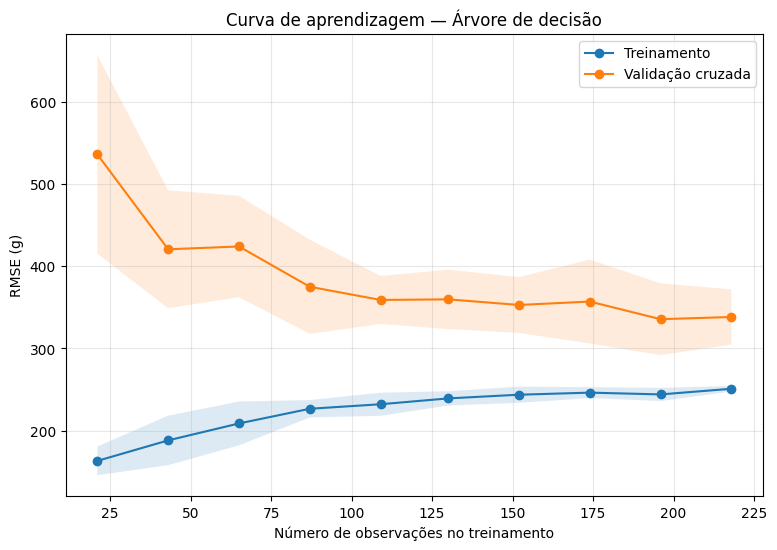

In [40]:
plt.figure(figsize=(9, 6))

plt.plot(
    curva_arvore["tamanhos"],
    curva_arvore["treino_media"],
    marker="o",
    label="Treinamento"
)

plt.fill_between(
    curva_arvore["tamanhos"],
    curva_arvore["treino_media"] - curva_arvore["treino_dp"],
    curva_arvore["treino_media"] + curva_arvore["treino_dp"],
    alpha=0.15
)

plt.plot(
    curva_arvore["tamanhos"],
    curva_arvore["validacao_media"],
    marker="o",
    label="Validação cruzada"
)

plt.fill_between(
    curva_arvore["tamanhos"],
    curva_arvore["validacao_media"] - curva_arvore["validacao_dp"],
    curva_arvore["validacao_media"] + curva_arvore["validacao_dp"],
    alpha=0.15
)

plt.xlabel("Número de observações no treinamento")
plt.ylabel("RMSE (g)")
plt.title("Curva de aprendizagem — Árvore de decisão")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 41. Curva de aprendizagem — Bagging

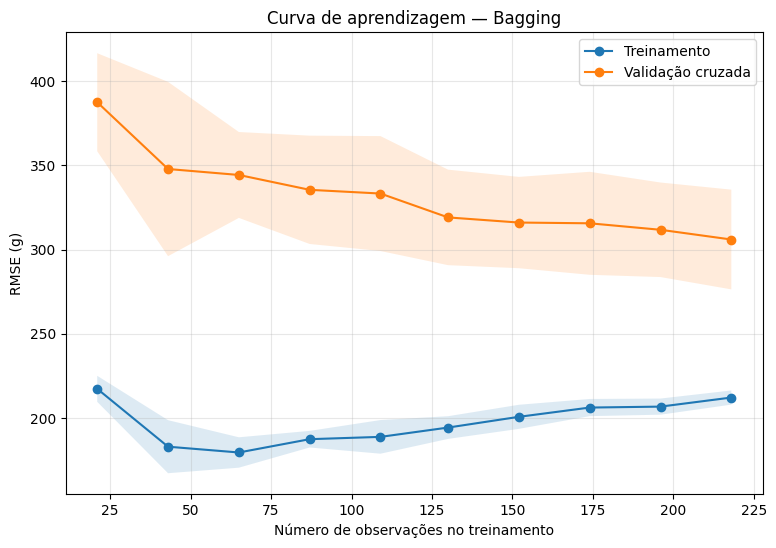

In [41]:
plt.figure(figsize=(9, 6))

plt.plot(
    curva_bagging["tamanhos"],
    curva_bagging["treino_media"],
    marker="o",
    label="Treinamento"
)

plt.fill_between(
    curva_bagging["tamanhos"],
    curva_bagging["treino_media"] - curva_bagging["treino_dp"],
    curva_bagging["treino_media"] + curva_bagging["treino_dp"],
    alpha=0.15
)

plt.plot(
    curva_bagging["tamanhos"],
    curva_bagging["validacao_media"],
    marker="o",
    label="Validação cruzada"
)

plt.fill_between(
    curva_bagging["tamanhos"],
    curva_bagging["validacao_media"] - curva_bagging["validacao_dp"],
    curva_bagging["validacao_media"] + curva_bagging["validacao_dp"],
    alpha=0.15
)

plt.xlabel("Número de observações no treinamento")
plt.ylabel("RMSE (g)")
plt.title("Curva de aprendizagem — Bagging")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 42. Curva de aprendizagem — Random Forest

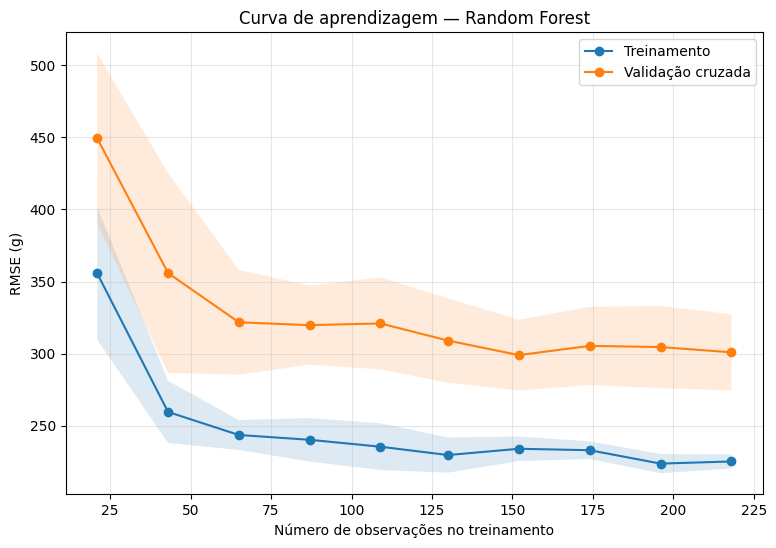

In [42]:
plt.figure(figsize=(9, 6))

plt.plot(
    curva_floresta["tamanhos"],
    curva_floresta["treino_media"],
    marker="o",
    label="Treinamento"
)

plt.fill_between(
    curva_floresta["tamanhos"],
    curva_floresta["treino_media"] - curva_floresta["treino_dp"],
    curva_floresta["treino_media"] + curva_floresta["treino_dp"],
    alpha=0.15
)

plt.plot(
    curva_floresta["tamanhos"],
    curva_floresta["validacao_media"],
    marker="o",
    label="Validação cruzada"
)

plt.fill_between(
    curva_floresta["tamanhos"],
    curva_floresta["validacao_media"] - curva_floresta["validacao_dp"],
    curva_floresta["validacao_media"] + curva_floresta["validacao_dp"],
    alpha=0.15
)

plt.xlabel("Número de observações no treinamento")
plt.ylabel("RMSE (g)")
plt.title("Curva de aprendizagem — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 43. Comparação direta do RMSE de validação

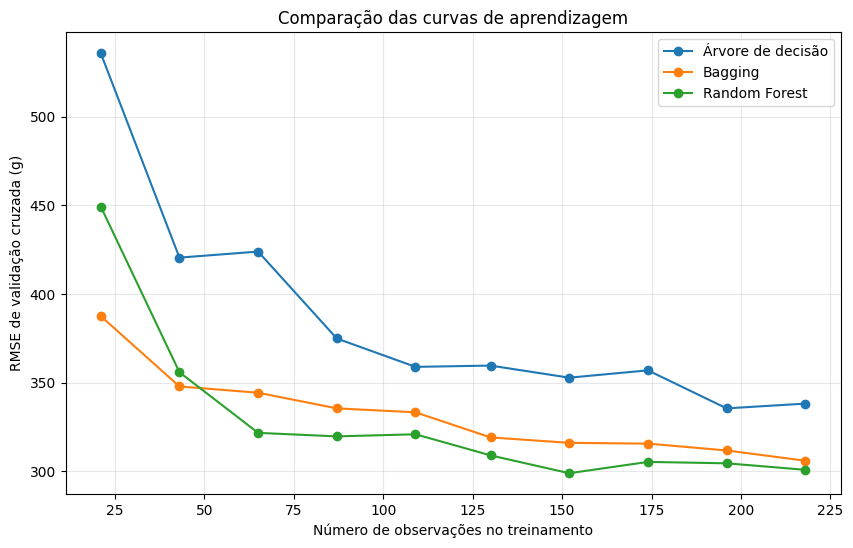

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(
    curva_arvore["tamanhos"],
    curva_arvore["validacao_media"],
    marker="o",
    label="Árvore de decisão"
)

plt.plot(
    curva_bagging["tamanhos"],
    curva_bagging["validacao_media"],
    marker="o",
    label="Bagging"
)

plt.plot(
    curva_floresta["tamanhos"],
    curva_floresta["validacao_media"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Número de observações no treinamento")
plt.ylabel("RMSE de validação cruzada (g)")
plt.title("Comparação das curvas de aprendizagem")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 44. Comparação do gap treino–validação

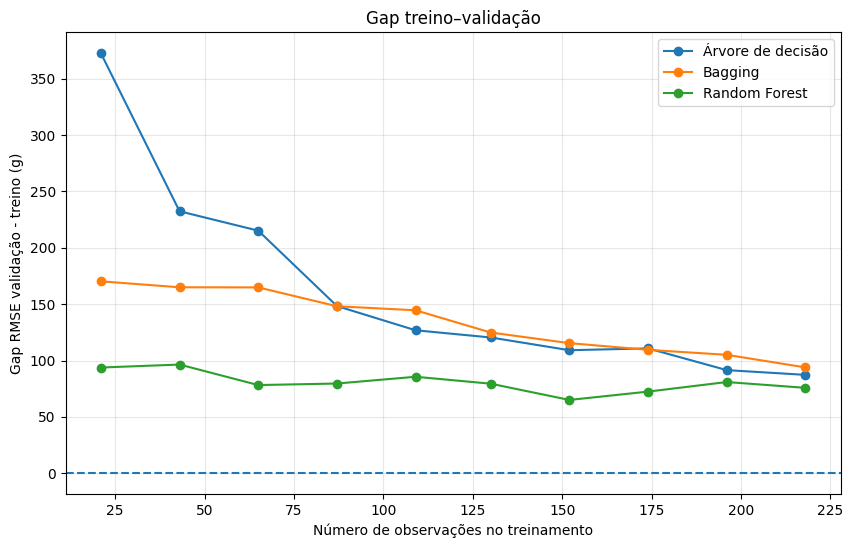

In [44]:
gap_arvore = (
    curva_arvore["validacao_media"]
    - curva_arvore["treino_media"]
)

gap_bagging = (
    curva_bagging["validacao_media"]
    - curva_bagging["treino_media"]
)

gap_floresta = (
    curva_floresta["validacao_media"]
    - curva_floresta["treino_media"]
)

plt.figure(figsize=(10, 6))

plt.plot(
    curva_arvore["tamanhos"],
    gap_arvore,
    marker="o",
    label="Árvore de decisão"
)

plt.plot(
    curva_bagging["tamanhos"],
    gap_bagging,
    marker="o",
    label="Bagging"
)

plt.plot(
    curva_floresta["tamanhos"],
    gap_floresta,
    marker="o",
    label="Random Forest"
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Número de observações no treinamento")
plt.ylabel("Gap RMSE validação - treino (g)")
plt.title("Gap treino–validação")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Guia de interpretação

**Alta variância / possível overfitting**

- RMSE de treinamento muito menor que o RMSE de validação;
- gap persistentemente grande.

**Alto viés / possível underfitting**

- RMSE de treinamento e validação relativamente altos;
- curvas próximas.

**Possível benefício de mais dados**

- RMSE de validação ainda cai claramente nos maiores tamanhos de amostra.

A expectativa teórica é que Bagging e Random Forest possam reduzir a variância da árvore individual, mas essa hipótese deve ser confirmada pelos resultados.

# Parte IX — Estrutura da Árvore Individual

## 45. Recuperar a árvore final

In [45]:
arvore_final = melhor_arvore.named_steps["modelo"]

pre_processador_arvore = (
    melhor_arvore
    .named_steps["pre_processamento"]
)

feature_names = (
    pre_processador_arvore
    .get_feature_names_out()
)

print("Profundidade:", arvore_final.get_depth())
print("Número de folhas:", arvore_final.get_n_leaves())
print("Número de nós:", arvore_final.tree_.node_count)

Profundidade: 4
Número de folhas: 16
Número de nós: 31


## 46. Visualização dos primeiros níveis

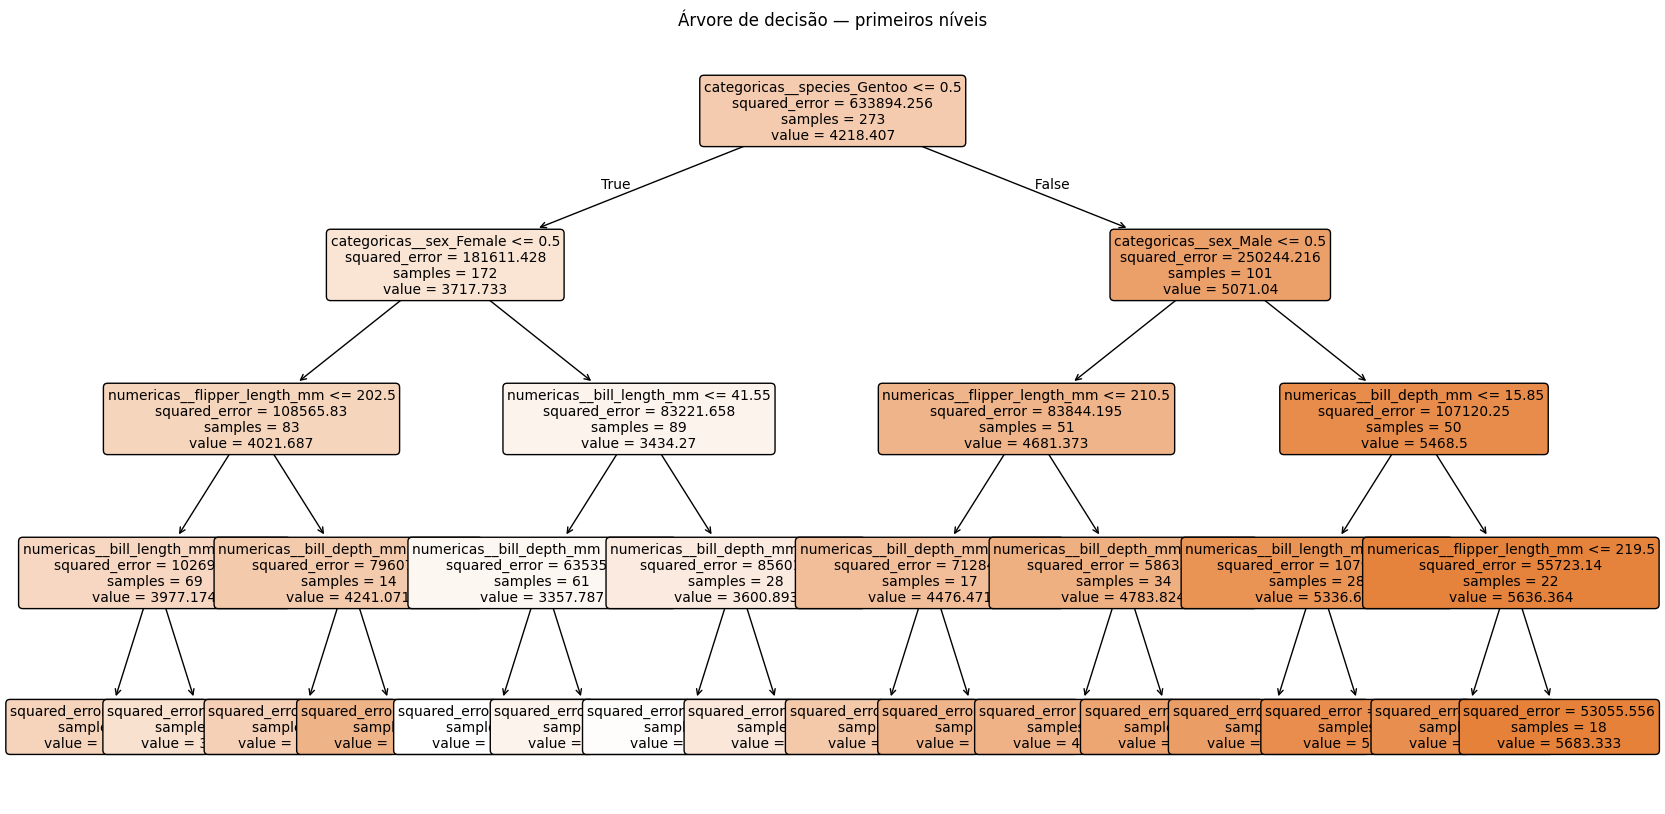

In [52]:
plt.figure(figsize=(20, 10))

plot_tree(
    arvore_final,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=4
)

plt.title("Árvore de decisão — primeiros níveis")
plt.show()

# Parte X — Importância das variáveis

## 47. Importância — Árvore

In [47]:
importancias_arvore = pd.DataFrame({
    "Variavel": feature_names,
    "Importancia": arvore_final.feature_importances_
})

importancias_arvore = (
    importancias_arvore
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)

display(importancias_arvore)

,Variavel,Importancia
0,categoricas__species_Gentoo,0.747306
1,categoricas__sex_Male,0.100306
2,categoricas__sex_Female,0.095028
3,numericas__bill_depth_mm,0.027945
4,numericas__bill_length_mm,0.015951
5,numericas__flipper_length_mm,0.013463
6,categoricas__species_Adelie,0.000000
7,categoricas__island_Biscoe,0.000000
8,categoricas__species_Chinstrap,0.000000
9,categoricas__island_Torgersen,0.000000


## 48. Importância — Random Forest

In [48]:
floresta_final = melhor_floresta.named_steps["modelo"]

pre_processador_floresta = (
    melhor_floresta
    .named_steps["pre_processamento"]
)

feature_names_floresta = (
    pre_processador_floresta
    .get_feature_names_out()
)

importancias_floresta = pd.DataFrame({
    "Variavel": feature_names_floresta,
    "Importancia": floresta_final.feature_importances_
})

importancias_floresta = (
    importancias_floresta
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)

display(importancias_floresta)

,Variavel,Importancia
0,numericas__flipper_length_mm,0.291431
1,categoricas__species_Gentoo,0.198791
2,numericas__bill_depth_mm,0.122577
3,numericas__bill_length_mm,0.082160
4,categoricas__island_Biscoe,0.081344
5,categoricas__sex_Female,0.063481
6,categoricas__sex_Male,0.057259
7,categoricas__species_Adelie,0.051655
8,categoricas__island_Dream,0.029565
9,categoricas__species_Chinstrap,0.020991


# Parte XI — Síntese final

## 49. Tabela conjunta de validação cruzada e teste

In [49]:
resumo_final = comparacao_cv.merge(
    comparacao_teste[
        comparacao_teste["Modelo"] != "Baseline"
    ],
    on="Modelo",
    how="left"
)

resumo_final = resumo_final[
    [
        "Modelo",
        "RMSE_treino_CV",
        "RMSE_validacao_CV",
        "Gap_CV",
        "DP_validacao_CV",
        "RMSE",
        "MAE",
        "R2",
        "Reducao_RMSE_vs_baseline_%"
    ]
]

resumo_final = resumo_final.rename(
    columns={
        "RMSE": "RMSE_teste",
        "MAE": "MAE_teste",
        "R2": "R2_teste"
    }
)

display(
    resumo_final.sort_values("RMSE_teste")
)

,Modelo,RMSE_treino_CV,RMSE_validacao_CV,Gap_CV,DP_validacao_CV,RMSE_teste,MAE_teste,R2_teste,Reducao_RMSE_vs_baseline_%
0,Random Forest,224.819808,301.175972,76.356164,27.043211,304.125585,249.482010,0.860897,62.893034
1,Bagging,210.971899,307.137997,96.166097,34.461391,309.173673,248.546464,0.856240,62.277107
2,Árvore de decisão,250.752037,339.023125,88.271088,32.564842,327.908786,263.480724,0.838290,59.991199


## 50. Melhores hiperparâmetros

In [50]:
print("ÁRVORE DE DECISÃO")
print(busca_arvore.best_params_)

print("\nBAGGING")
print(busca_bagging.best_params_)

print("\nRANDOM FOREST")
print(busca_floresta.best_params_)

ÁRVORE DE DECISÃO
{'modelo__max_depth': 4, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 2}

BAGGING
{'modelo__bootstrap': True, 'modelo__estimator__max_depth': 5, 'modelo__estimator__min_samples_leaf': 1, 'modelo__max_samples': 0.7, 'modelo__n_estimators': 200}

RANDOM FOREST
{'modelo__bootstrap': False, 'modelo__max_depth': 8, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 100}
